In [ ]:
#라이브러리 설치 

In [1]:
!python -m pip install pandas matplotlib folium seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
#라이브러리 임포트

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [9]:
#데이터 가공   bikerentl-data 폴더 속 파일들을 이용할 것.  깨지니까 EUC KR로 인코딩한다. 

In [10]:
bike_temp = pd.read_csv('../data/bikerental-data/bike_rent_1.csv',  encoding='cp949', parse_dates=['대여일시'])
bike_temp.head()


,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [11]:
bike_dictionary = {}
for file_number in range(1, 7):
    bike_csv = pd.read_csv(f'../data/bikerental-data/bike_rent_{file_number}.csv',  encoding='cp949', parse_dates=['대여일시'])
    bike_dictionary[file_number] = bike_csv


In [12]:
bike_dictionary

{1:             자전거번호                대여일시  대여 대여소번호            대여 대여소명  이용시간  이용거리
 0       SPB-22040 2019-06-03 08:49:00       646  장한평역 1번출구 (국민은행앞)    27  1330
 1       SPB-07446 2019-06-03 08:33:00       526           용답토속공원 앞    54  1180
 2       SPB-20387 2019-06-05 08:27:00       646  장한평역 1번출구 (국민은행앞)    12  1930
 3       SPB-16794 2019-06-05 08:46:00       646  장한평역 1번출구 (국민은행앞)     6  1340
 4       SPB-18266 2019-06-10 08:27:00       529       장한평역 8번 출구 앞     5  1230
 ...           ...                 ...       ...                ...   ...   ...
 399994  SPB-16680 2019-06-28 17:14:00       316         종각역 1번출구 앞    16  2360
 399995  SPB-07874 2019-06-28 16:59:00       345         서울보증보험본사 앞    32  1880
 399996  SPB-21622 2019-06-28 16:44:00       526           용답토속공원 앞    64  6100
 399997  SPB-20056 2019-06-28 17:46:00       453  종로오가 지하쇼핑센터 14번출구     7   880
 399998  SPB-18692 2019-06-28 17:34:00       345         서울보증보험본사 앞    35  1820
 
 [399999 rows x 6 columns],
 2:    

In [13]:
#scrolloed element 보면 전체 데이터 볼 수 있다. 

print(type(bike_dictionary))

<class 'dict'>


In [14]:
print(type(bike_dictionary[1]))  #1번부터 프린트한다. 0번은 없음. 

<class 'pandas.DataFrame'>


In [15]:
#DataFrame 합치기 (concat)
#ignore_index 기존 인덱스를 무시하고 다시 순서를 0부터 생성한다. 

bikes = pd.concat(bike_dictionary, ignore_index=True)  #인덱스가 만약 겹친다면 하나로 합치라는 의미. ignore inex가 트루가 된다. 
bikes.head()


,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [16]:
bikes.iloc[39995:40005]

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
39995,SPB-13466,2019-06-02 15:51:00,142,아현역 4번출구 앞,26,3290
39996,SPB-19471,2019-06-02 16:06:00,112,극동방송국 앞,12,1090
39997,SPB-05619,2019-06-02 16:03:00,112,극동방송국 앞,17,1180
39998,SPB-06198,2019-06-02 16:07:00,112,극동방송국 앞,14,1170
39999,SPB-22101,2019-06-02 15:59:00,198,충정2교,23,4500
40000,SPB-05524,2019-06-02 15:58:00,3104,e편한세상 신촌4단지 앞,24,3590
40001,SPB-12238,2019-06-02 16:25:00,148,용강동 주민센터 앞,16,3080
40002,SPB-07219,2019-06-02 16:28:00,109,제일빌딩 앞,19,1740
40003,SPB-19839,2019-06-02 15:56:00,116,일진아이윌아파트 옆,49,3380
40004,SPB-20020,2019-06-02 16:29:00,109,제일빌딩 앞,19,1610


In [15]:
bikes.tail()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030
2215631,SPB-14209,2019-06-28 07:37:00,240,문래역 4번출구 앞,6,1010


In [16]:
bikes.info()  #정보 보는 함수. describe라는 메소드도 있다.#각 데이터의 데이터타입을 볼 수 있다. 

<class 'pandas.DataFrame'>
RangeIndex: 2215632 entries, 0 to 2215631
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     str           
 1   대여일시      datetime64[us]
 2   대여 대여소번호  int64         
 3   대여 대여소명   str           
 4   이용시간      int64         
 5   이용거리      int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 101.4 MB


In [17]:
bikes.shape

(2215632, 6)

In [18]:
bikes.describe()

,대여일시,대여 대여소번호,이용시간,이용거리
count,2215632,2.215632e+06,2.215632e+06,2.215632e+06
mean,2019-06-16 08:40:01.500303,1.226154e+03,2.716998e+01,3.912916e+03
min,2019-06-01 00:00:00,3.000000e+00,1.000000e+00,0.000000e+00
25%,2019-06-08 22:04:00,5.050000e+02,8.000000e+00,1.220000e+03
50%,2019-06-16 15:13:00,1.159000e+03,1.700000e+01,2.270000e+03
75%,2019-06-23 20:22:00,1.846000e+03,3.700000e+01,4.670000e+03
max,2019-06-30 23:59:00,9.998000e+03,3.133000e+03,2.323100e+05
std,NaN,8.499197e+02,2.908119e+01,5.145471e+03


In [19]:
bikes.index

RangeIndex(start=0, stop=2215632, step=1)

In [20]:
bikes.columns

Index(['자전거번호', '대여일시', '대여 대여소번호', '대여 대여소명', '이용시간', '이용거리'], dtype='str')

In [21]:
bikes.dtypes

자전거번호                  str
대여일시        datetime64[us]
대여 대여소번호             int64
대여 대여소명                str
이용시간                 int64
이용거리                 int64
dtype: object

In [17]:
pd.options.display.float_format='{:.2f}'.format

In [18]:
bikes.describe(include=['object','datetime64'])

C:\Users\EL022\AppData\Local\Temp\ipykernel_22516\348355680.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  bikes.describe(include=['object','datetime64'])


,자전거번호,대여일시,대여 대여소명
count,2215632,2215632,2215632
unique,19029,NaN,1543
top,SPB-17237,NaN,뚝섬유원지역 1번출구 앞
freq,292,NaN,12617
mean,NaN,2019-06-16 08:40:01.500303,NaN
min,NaN,2019-06-01 00:00:00,NaN
25%,NaN,2019-06-08 22:04:00,NaN
50%,NaN,2019-06-16 15:13:00,NaN
75%,NaN,2019-06-23 20:22:00,NaN
max,NaN,2019-06-30 23:59:00,NaN


In [19]:
bikes.isnull()

#null값이 뭐가 있는지 확인한다 - False는 null값이 없다는 뜻 

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
2215627,False,False,False,False,False,False
2215628,False,False,False,False,False,False
2215629,False,False,False,False,False,False
2215630,False,False,False,False,False,False


In [ ]:
bikes.isnull().sum()

#null인 데이터는 없는 데이터다. 그러면 데이터 처리하기가 굉장히 쉬워진다. 

자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
dtype: int64

In [24]:
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [20]:
bikes['대여일시']

0         2019-06-03 08:49:00
1         2019-06-03 08:33:00
2         2019-06-05 08:27:00
3         2019-06-05 08:46:00
4         2019-06-10 08:27:00
                  ...        
2215627   2019-06-24 07:40:00
2215628   2019-06-25 07:34:00
2215629   2019-06-26 08:19:00
2215630   2019-06-27 07:38:00
2215631   2019-06-28 07:37:00
Name: 대여일시, Length: 2215632, dtype: datetime64[us]

In [21]:
bikes['대여일시'].dt.day

#day만을 뽑아왔다. 

0           3
1           3
2           5
3           5
4          10
           ..
2215627    24
2215628    25
2215629    26
2215630    27
2215631    28
Name: 대여일시, Length: 2215632, dtype: int32

In [22]:
#없는 칼럼을 새로 만든다. '일자'라는 칼럼. 
bikes['일자'] = bikes['대여일시'].dt.day
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10


In [23]:
bikes['대여일시'].dt.hour

0          8
1          8
2          8
3          8
4          8
          ..
2215627    7
2215628    7
2215629    8
2215630    7
2215631    7
Name: 대여일시, Length: 2215632, dtype: int32

In [24]:
bikes['대여시간대'] = bikes['대여일시'].dt.hour
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8


In [25]:
#주말에는 더 많이 대여할까? 
weeks = ['월','화','수','목','금','토','일']
weeks

['월', '화', '수', '목', '금', '토', '일']

In [26]:
bikes['대여일시'].dt.dayofweek

0          0
1          0
2          2
3          2
4          0
          ..
2215627    0
2215628    1
2215629    2
2215630    3
2215631    4
Name: 대여일시, Length: 2215632, dtype: int32

In [27]:
bikes['대여일시'].dt.dayofweek.apply(lambda x : weeks[x])  #월요일부터 0이 할당된다. 


0          월
1          월
2          수
3          수
4          월
          ..
2215627    월
2215628    화
2215629    수
2215630    목
2215631    금
Name: 대여일시, Length: 2215632, dtype: str

In [28]:
#대여일시에서 dayofweek을 추출해서 요일 컬럼으로 추가하기 
#이때 요일이 숫자이므로 요일 이름으로 변환해서 추가 
bikes['요일'] = bikes['대여일시'].dt.dayofweek.apply(lambda x : weeks[x]) 
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월


In [29]:
bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')

0          평일
1          평일
2          평일
3          평일
4          평일
           ..
2215627    평일
2215628    평일
2215629    평일
2215630    평일
2215631    평일
Name: 대여일시, Length: 2215632, dtype: str

In [30]:
temp1 = bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')
temp1.head()

0    평일
1    평일
2    평일
3    평일
4    평일
Name: 대여일시, dtype: str

In [31]:
temp1[temp1 == '주말']

23         주말
32         주말
33         주말
34         주말
35         주말
           ..
2215590    주말
2215591    주말
2215614    주말
2215615    주말
2215619    주말
Name: 대여일시, Length: 737033, dtype: str

In [32]:
#여기부터 선생님 자료 비교하면서 틀린거 고치기 

temp2 = bikes['요일'].apply(lambda x: '평일' if x != '토' and x != '일' else '주말')
temp2.head()

0    평일
1    평일
2    평일
3    평일
4    평일
Name: 요일, dtype: str

In [33]:
bikes['주말구분'] = bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일


In [ ]:
#장소적 특성에 따른 컬럼 추가 

In [34]:
bike_shop = pd.read_csv('../data/bikerental-data/bike_shop.csv',  encoding='cp949')
bike_shop.head()

,구분,대여소번호,대여소명,위도,경도,거치대수
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91,5
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91,20
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91,14
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91,13
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91,5


In [35]:
bike_shop.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      1537 non-null   str    
 1   대여소번호   1537 non-null   int64  
 2   대여소명    1537 non-null   str    
 3   위도      1537 non-null   float64
 4   경도      1537 non-null   float64
 5   거치대수    1537 non-null   int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 72.2 KB


In [36]:
bike_gu = bike_shop[['구분','대여소번호','대여소명','위도','경도']]
bike_gu.head()

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91


In [37]:
#bikes와 merge할 거다. 

bikes_merged = pd.merge(bikes, bike_gu, left_on='대여 대여소번호', right_on='대여소번호')
bikes_merged.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,대여소번호,대여소명,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,526,526. 용답토속공원 앞,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,529,529. 장한평역 8번 출구 앞,37.56,127.06


In [38]:
#몇개 칼럼을 drop을 해보려 한다. 

bikes_dropped = bikes_merged.drop(['대여소번호', '대여소명'], axis=1)
bikes_dropped.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,37.56,127.06


In [39]:
bikes_renamed = bikes_dropped.rename(columns={'구분':'대여구','위도':'대여점위도','경도':'대여점경도'})
bikes_renamed.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,대여구,대여점위도,대여점경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,37.56,127.06


In [ ]:
#시간에 따른 시각화

In [40]:
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns
#import folium

plt.rc('font', family = 'Malgun gothic')
plt.rc('axes', unicode_minus=False)

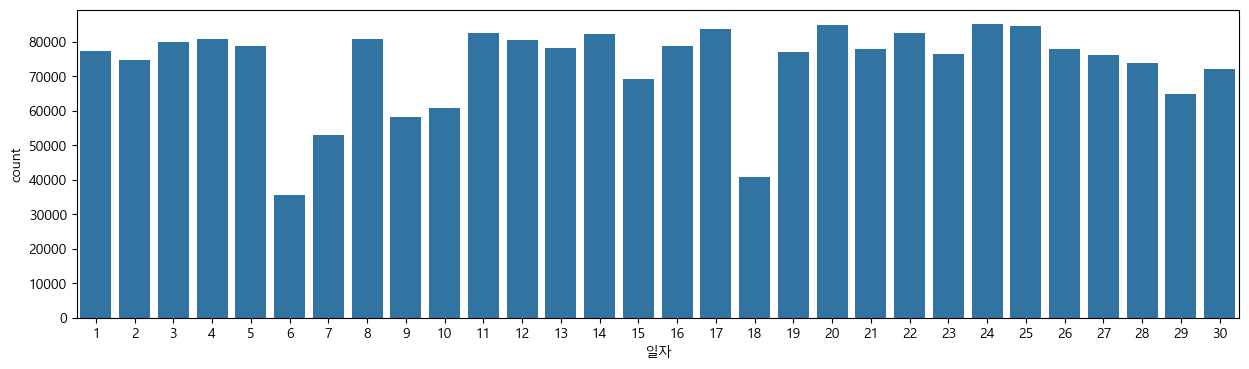

In [41]:
plt.figure(figsize= (15, 4))
sns.countplot(data=bikes_renamed, x='일자')
plt.show()    #6, 18일에는 대여 횟수가 좀 적었다. 

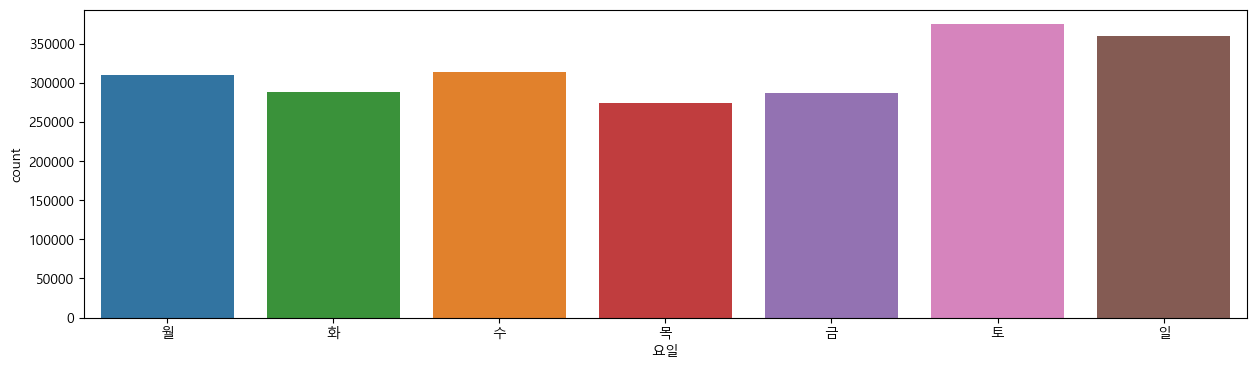

In [42]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='요일', hue='요일', order=['월','화','수','목','금','토','일'])  #order를 넣지 않으면 월화수가 순서대로 안나온다
plt.show()

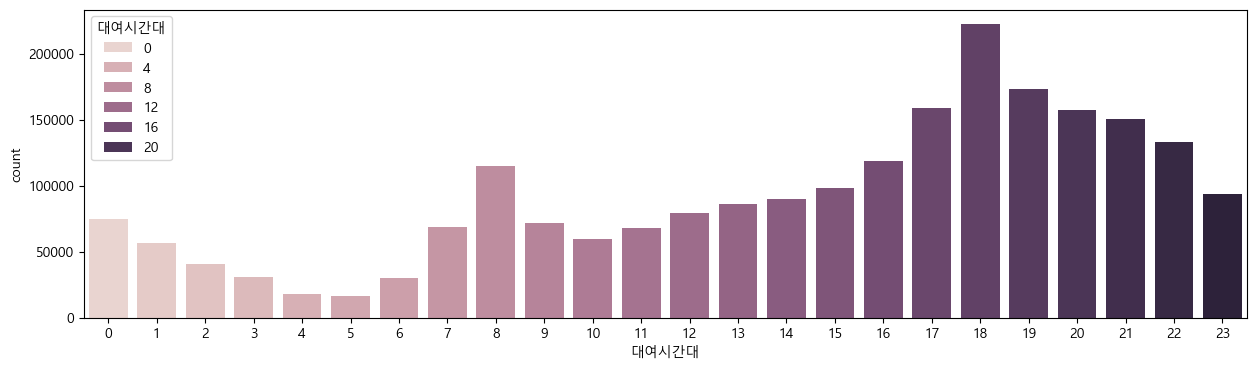

In [43]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='대여시간대', hue='대여시간대')  #hue가 없으면 그라데이션도 없다. 
plt.show()

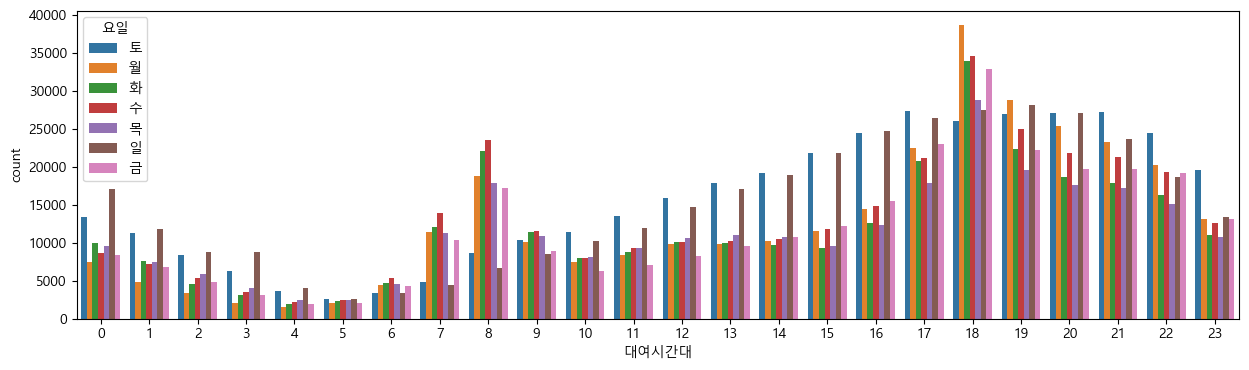

In [44]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='대여시간대', hue='요일')  #hue가 없으면 그라데이션도 없다. 
plt.show() 

In [45]:
hourly_dayofweek_ride = bikes_renamed.pivot_table(index='대여시간대',columns='요일', values='자전거번호',aggfunc='count')  
hourly_dayofweek_ride.head()

요일,금,목,수,월,일,토,화
대여시간대,,,,,,,
0,8353,9568,8624,7461,17025,13438,9907
1,6748,7508,7226,4846,11731,11232,7529
2,4762,5857,5328,3305,8804,8348,4497
3,3045,3992,3430,2102,8748,6221,3157
4,1979,2402,2160,1544,4076,3584,1971


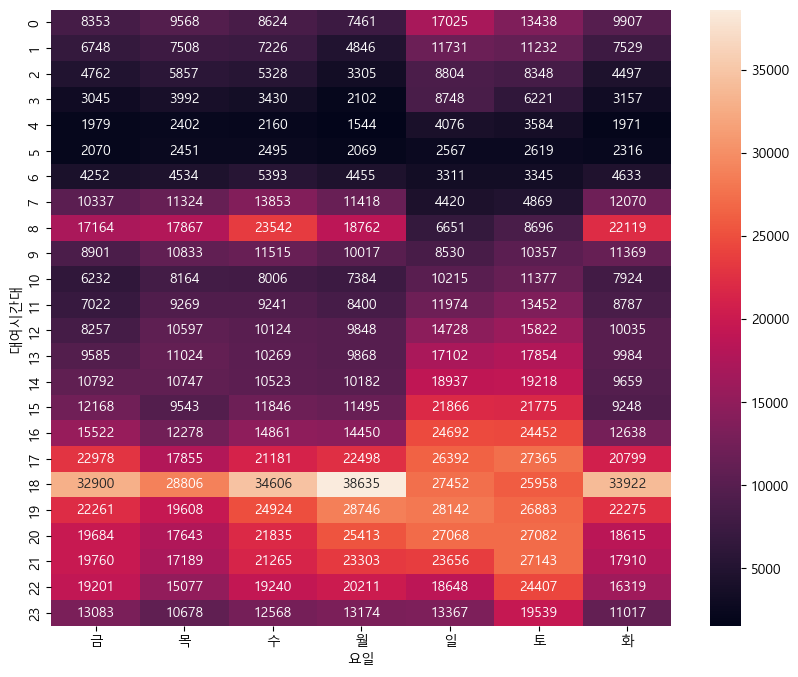

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(data=hourly_dayofweek_ride, annot=True, fmt='d')  #annot는 주석
pass

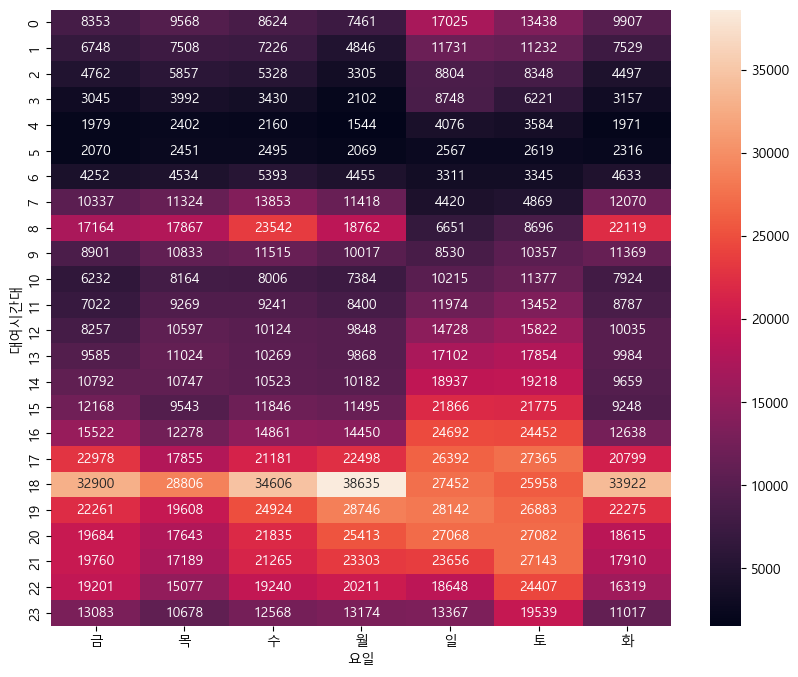

In [47]:
plt.figure(figsize=(10,8))
sns.heatmap(data=hourly_dayofweek_ride, annot=True, fmt='d')  #annot는 주석, True면 숫자가 나오고, False면 숫자가 안 나온다
pass 

In [ ]:
#주말 구분 시각화

In [48]:
bikes_renamed

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,대여구,대여점위도,대여점경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,37.56,127.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2209344,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900,24,7,월,평일,영등포구,37.52,126.90
2209345,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880,25,7,화,평일,영등포구,37.52,126.90
2209346,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930,26,8,수,평일,영등포구,37.52,126.90
2209347,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030,27,7,목,평일,영등포구,37.52,126.90


In [49]:
weekends_dayofweek_ride = bikes_renamed.pivot_table(index='대여시간대',columns='주말구분', values='자전거번호',aggfunc='count')  
weekends_dayofweek_ride.head()

주말구분,주말,평일
대여시간대,,
0,30463,43913
1,22963,33857
2,17152,23749
3,14969,15726
4,7660,10056


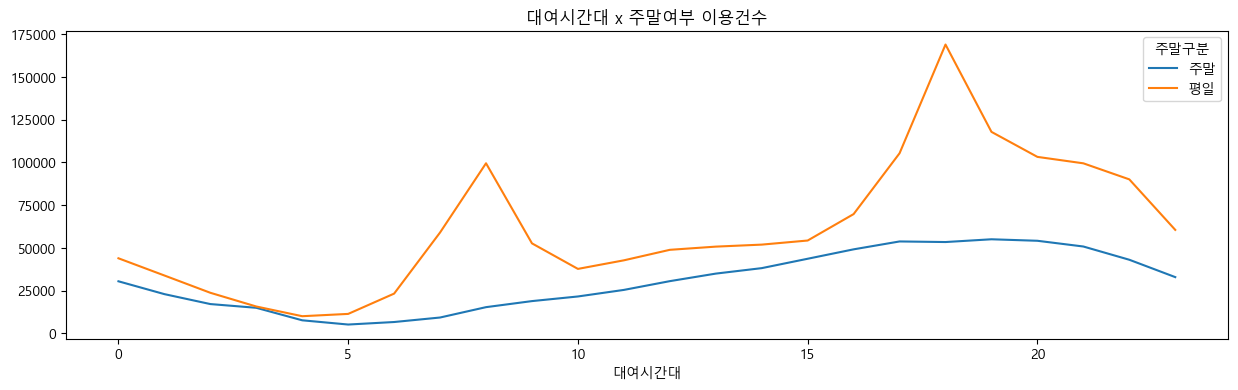

In [50]:
weekends_dayofweek_ride.plot(kind='line', title='대여시간대 x 주말여부 이용건수', figsize=(15, 4))
pass

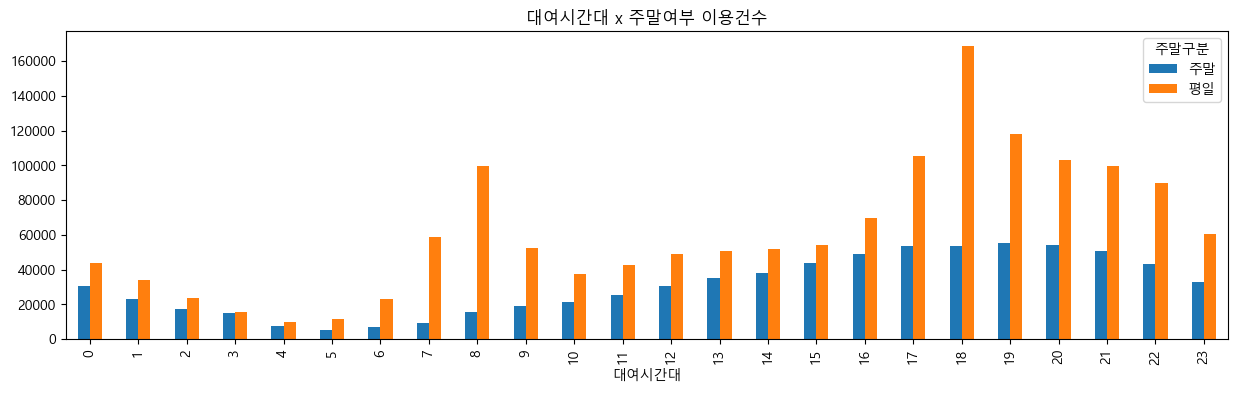

In [51]:
weekends_dayofweek_ride.plot(kind='bar', title='대여시간대 x 주말여부 이용건수', figsize=(15, 4))
pass

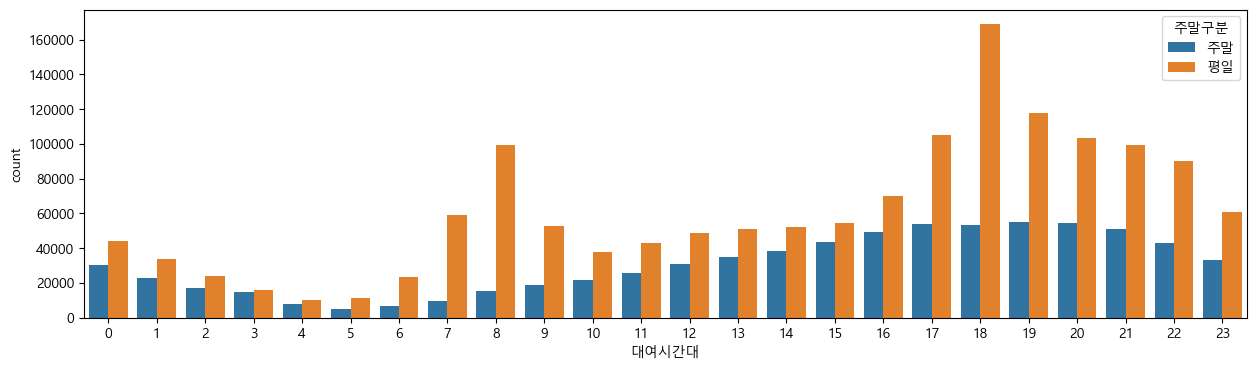

In [52]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='대여시간대', hue='주말구분')
pass

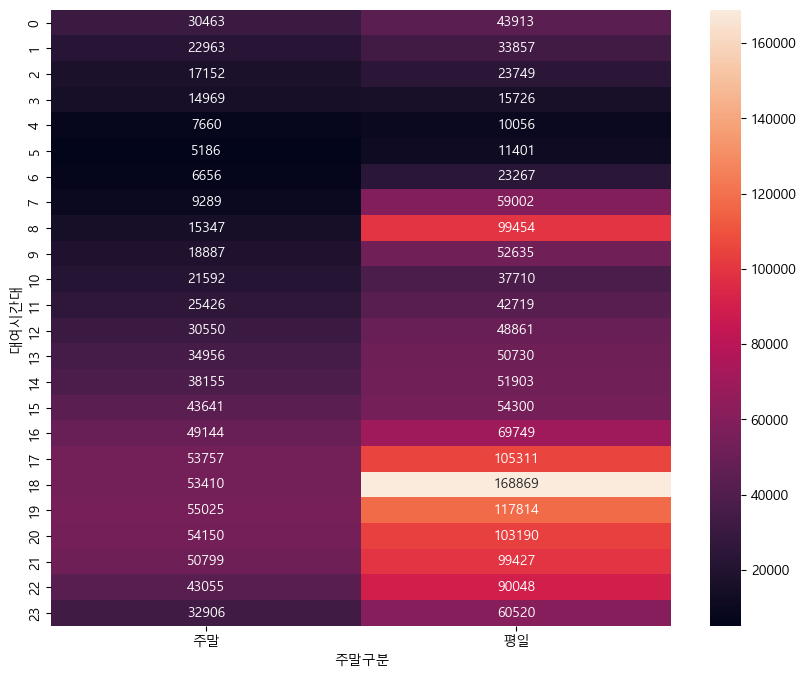

In [53]:
plt.figure(figsize=(10, 8))
sns.heatmap(data=weekends_dayofweek_ride, annot=True, fmt='d')
pass

In [ ]:
#장소에 따른 시각화

In [54]:
number_of_ride_per_gu = bikes_renamed.pivot_table(index='대여구', values='자전거번호', aggfunc='count')
number_of_ride_per_gu

,자전거번호
대여구,
강남구,97081
강동구,78231
강북구,40563
강서구,141006
관악구,83382
광진구,141996
구로구,78696
금천구,33488
노원구,113823


In [55]:
number_of_ride_per_gu_sorted = number_of_ride_per_gu.sort_values(by='자전거번호', ascending=True)  #제일 높은 순으로 정렬
number_of_ride_per_gu_sorted.head()

,자전거번호
대여구,
금천구,33488
도봉구,38697
강북구,40563
용산구,47993
중구,48533


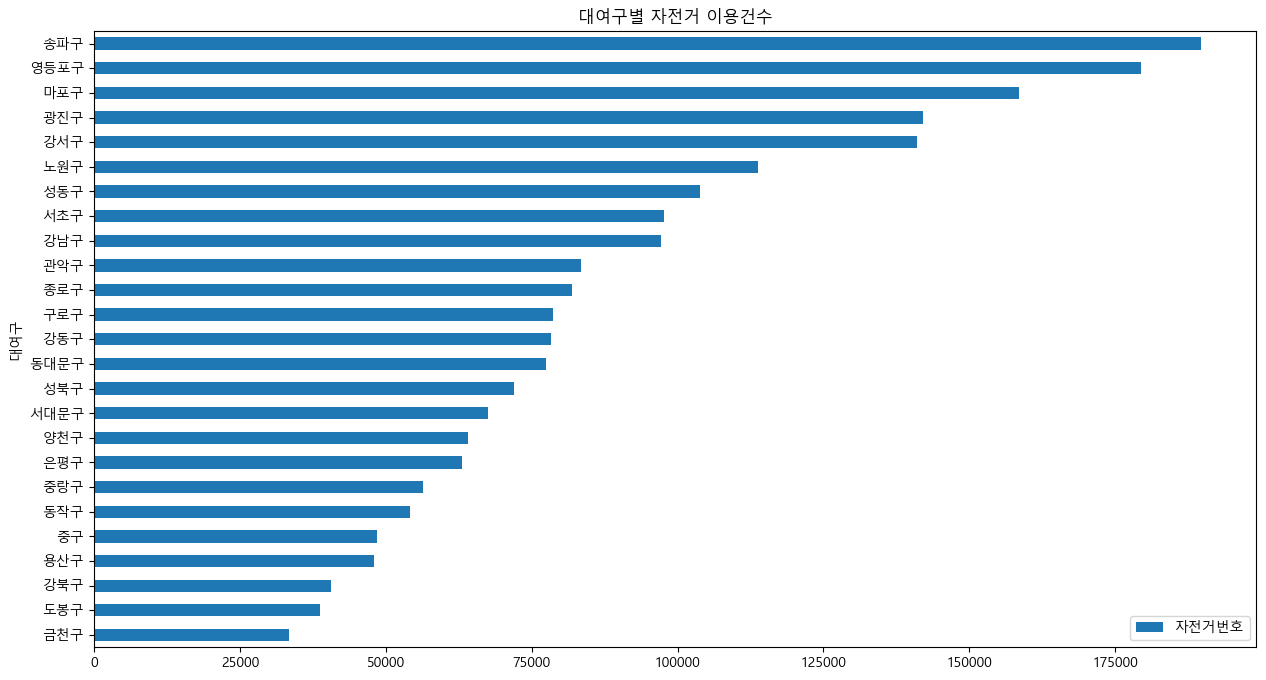

In [56]:
number_of_ride_per_gu_sorted.plot(kind='barh',figsize=(15,8), title='대여구별 자전거 이용건수')
pass

In [57]:
import json 

with open('../data/visualization-data/seoul.json', 'r', encoding='utf-8') as f:
    seoul_map = json.load(f)

seoul_map

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'code': '11250',
    'name': '강동구',
    'name_eng': 'Gangdong-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.11519584981606, 37.557533180704915],
      [127.11540412678968, 37.557491025257455],
      [127.1165206546129, 37.557268061772696],
      [127.1175954493625, 37.55705301284316],
      [127.11879551821994, 37.557222485451305],
      [127.11969651045837, 37.558176474822524],
      [127.12057912633198, 37.5590144597372],
      [127.12146867175024, 37.55986003393365],
      [127.12240146859469, 37.5604208685133],
      [127.12287911525227, 37.56070873375976],
      [127.12303576608339, 37.56078573052513],
      [127.12435254630417, 37.56144246249796],
      [127.12447748580927, 37.56148569898355],
      [127.13349006006634, 37.56465664804646],
      [127.13357625665371, 37.56468978043648],
      [127.1336638698021, 37.56472375596808],
      [127.133755022522

In [58]:
lat = bikes_renamed['대여점위도'].mean() #latitude의 약자
lon = bikes_renamed['대여점경도'].mean()
print(lat, lon)

37.547349884422054 126.99171375923994


In [59]:
map1 = folium.Map(location=[lat,lon], zoom_star=11)
map1

In [60]:
map2 = folium.Map(location=[lat,lon], zoom_star=11)
map3 = folium.Map(location=[lat,lon], zoom_star=11)
map4 = folium.Map(location=[lat,lon], zoom_star=11)

In [61]:
number_of_ride_per_gu_reset_index = number_of_ride_per_gu.reset_index()
number_of_ride_per_gu_reset_index.head()

,대여구,자전거번호
0,강남구,97081
1,강동구,78231
2,강북구,40563
3,강서구,141006
4,관악구,83382


In [62]:
folium.Choropleth(geo_data=seoul_map, 
                  data=number_of_ride_per_gu_reset_index, 
                  columns=['대여구','자전거번호'],
                    key_on='feature.properties.name',
                    fill_color='YlGnBu').add_to(map2)
map2

In [ ]:
#프로그래밍이 처음이라면 문법은 쉬우니까 배우긴 배우고, 코딩 에이전트를 끼고 연습해야 한다. 코덱스나 클로드, 제미나이 안티그래비티 등. 프롬프트 입력하는 방법을 알아야 한다. 